In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)

In [2]:
# ============================================================
# CELL 1 — Initialize SLM + camera and load correction file
#
# Important:
#   wavefront_phase is ONLY a NumPy array at this stage.
#   It is NOT yet installed as an SLM correction.
# ============================================================

from pathlib import Path
import numpy as np

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.alliedvision import AlliedVision
from slmsuite.hardware.cameraslms import FourierSLM


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts"
    r"\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut"
)

WAVEFRONT_PHASE_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts"
    r"\YDFC_wavefront_phase_processed_R2p80_50ms_dark.npy"
)


# ------------------------------------------------------------
# Initialize hardware ONCE in this notebook
# ------------------------------------------------------------

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(LUT_PATH),
    wav_um=0.7593,
    verbose=True,
)

cam = AlliedVision(
    serial="015C2",
    verbose=True,
)

fs = FourierSLM(cam, slm)


# ------------------------------------------------------------
# Load the measured correction from disk
#
# This only creates a NumPy array called wavefront_phase.
# It does NOT activate the correction.
# ------------------------------------------------------------

wavefront_phase = np.load(WAVEFRONT_PHASE_PATH)


# ------------------------------------------------------------
# Inspect our starting state
# ------------------------------------------------------------

print("SLM shape:", slm.shape)
print("Camera shape:", cam.shape)

print("\nLoaded correction:")
print(" shape :", wavefront_phase.shape)
print(" finite:", np.all(np.isfinite(wavefront_phase)))
print(" min   :", wavefront_phase.min())
print(" max   :", wavefront_phase.max())

print("\nCurrent slm.source keys:")
print(slm.source.keys())

print("\nGlobal default slm.phase_correct:")
print(slm.phase_correct)

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...vmbpy initializing... success
Looking for cameras... success
vmbpy sn '015C2' initializing... success
SLM shape: (1200, 1920)
Camera shape: (3672, 5496)

Loaded correction:
 shape : (1200, 1920)
 finite: True
 min   : 0.0
 max   : 6.2831762207757835

Current slm.source keys:
dict_keys([])

Global default slm.phase_correct:
True


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameras\camera.py:444: UserWarning: '015C2' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")


In [3]:
cal_file = r"c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_fourier_pre_wavefront_00000.h5"

loaded = fs.load_calibration(
    "fourier",
    file_path=cal_file
)

print("Loaded:", loaded)
print("Current calibrations:", fs.calibrations.keys())

print("Current calibrations:")
print(fs.calibrations.keys())

Loaded: c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_fourier_pre_wavefront_00000.h5
Current calibrations: dict_keys(['fourier'])
Current calibrations:
dict_keys(['fourier'])


In [4]:
print("SLM:", slm)
print("Camera:", cam)
print("FourierSLM:", fs)

print("\nCurrent calibrations:")
print(fs.calibrations.keys())

SLM: <slmsuite.hardware.slms.meadowlark.Meadowlark object at 0x000001D819D07830>
Camera: <slmsuite.hardware.cameras.alliedvision.AlliedVision object at 0x000001D8390CA1B0>
FourierSLM: <slmsuite.hardware.cameraslms.FourierSLM object at 0x000001D85A3803B0>

Current calibrations:
dict_keys(['fourier'])


In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

logo_path = r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Fun project\images\kunal.png"

img_logo = Image.open(logo_path)

print("Image mode:", img_logo.mode)
print("Image size:", img_logo.size)

Image mode: RGBA
Image size: (997, 904)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

rgba = np.array(img_logo.convert("RGBA"))

rgb = rgba[..., :3].astype(np.float32) / 255.0
alpha = rgba[..., 3].astype(np.float32) / 255.0

# Convert RGB to grayscale
gray = (
    0.299 * rgb[..., 0] +
    0.587 * rgb[..., 1] +
    0.114 * rgb[..., 2]
)

print("Gray min/max:", gray.min(), gray.max())
print("Alpha min/max:", alpha.min(), alpha.max())

Gray min/max: 0.020611767 1.0
Alpha min/max: 1.0 1.0


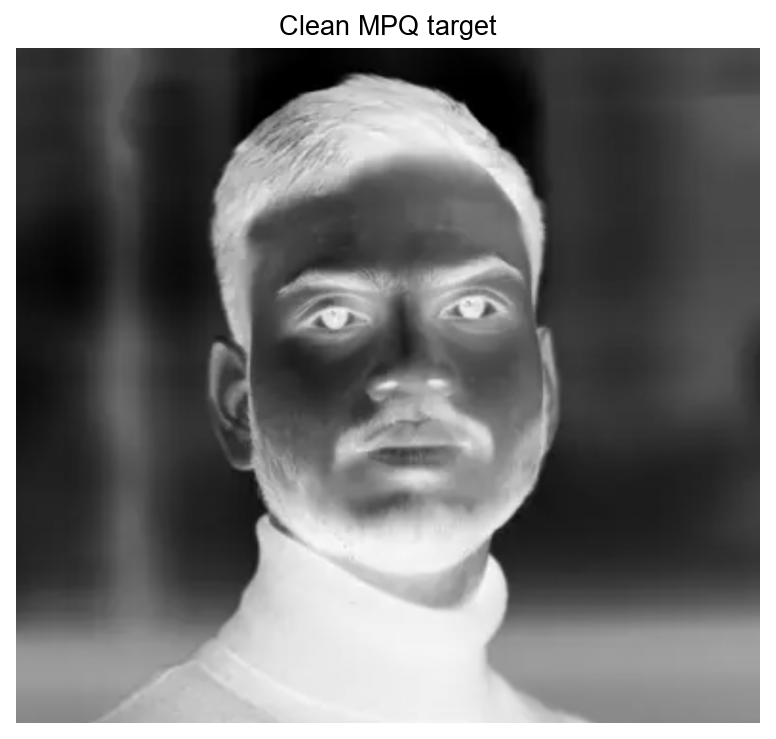

In [7]:
logo_clean = (1.0 - gray) * alpha

# Normalize
if logo_clean.max() > 0:
    logo_clean /= logo_clean.max()

plt.figure(figsize=(6, 6))
plt.imshow(logo_clean, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("Clean MPQ target")
plt.show()

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------
# 1. Get calibrated zero order
# --------------------------------
zero_ij = np.asarray(
    fs.kxyslm_to_ijcam((0, 0))
).reshape(-1)

x0 = float(zero_ij[0])
y0 = float(zero_ij[1])

print("Zero order:", x0, y0)

# --------------------------------
# 2. Resize MPQ logo
# --------------------------------
orig_h, orig_w = logo_clean.shape

target_w = 1200
scale = target_w / orig_w

target_h = int(round(orig_h * scale))

logo_resized = cv2.resize(
    logo_clean,
    (target_w, target_h),
    interpolation=cv2.INTER_AREA
)

print("Original shape:", logo_clean.shape)
print("Resized shape :", logo_resized.shape)

Zero order: 4366.832330787704 1826.7950847761629
Original shape: (904, 997)
Resized shape : (1088, 1200)


In [9]:
# Camera dimensions
H, W = fs.cam.shape

target_ij = np.zeros((H, W), dtype=np.float32)

# Desired logo center
cx = int(x0 - 700)
cy = int(y0)

logo_h, logo_w = logo_resized.shape

x1 = int(cx - logo_w / 2)
x2 = x1 + logo_w

y1 = int(cy - logo_h / 2)
y2 = y1 + logo_h

target_ij[y1:y2, x1:x2] = logo_resized

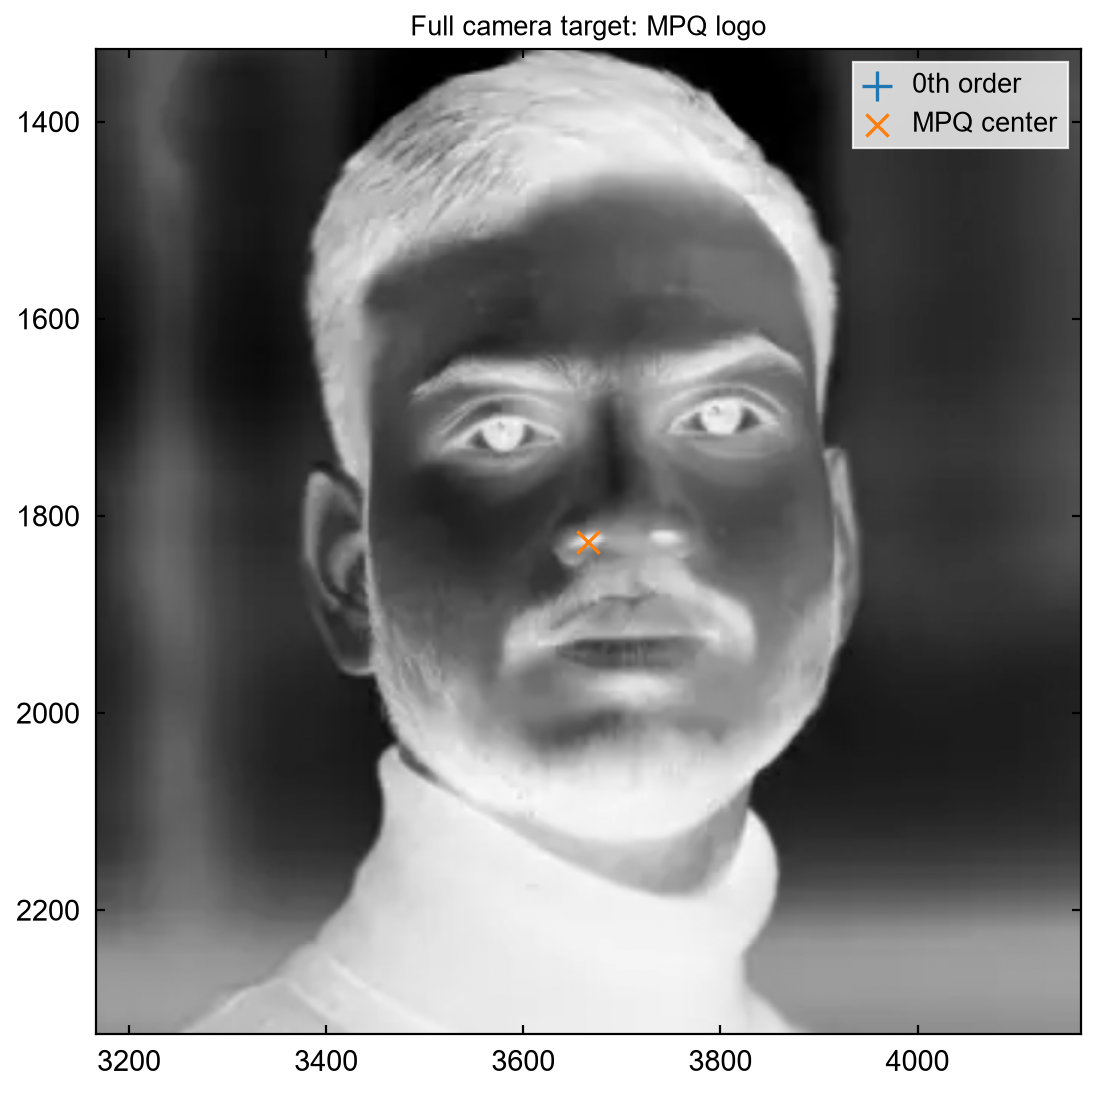

In [10]:
plt.figure(figsize=(8, 8))

plt.imshow(
    target_ij,
    cmap="gray",
    origin="upper"
)

plt.scatter(x0, y0, marker="+", s=180, label="0th order")
plt.scatter(cx, cy, marker="x", s=100, label="MPQ center")

plt.xlim(cx - 500, cx + 500)
plt.ylim(cy + 500, cy - 500)

plt.legend()
plt.title("Full camera target: MPQ logo")

plt.show()

In [11]:
from slmsuite.holography.algorithms import FeedbackHologram

holo_mpq = FeedbackHologram(
    shape=fs.slm.shape,
    target_ij=target_ij,
    cameraslm=fs
)

print("MPQ hologram object created.")
print("SLM shape:", fs.slm.shape)
print("Camera target shape:", target_ij.shape)

MPQ hologram object created.
SLM shape: (1200, 1920)
Camera target shape: (3672, 5496)


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:379: UserWarning: Hologram target shape (1200, 1920) is not a power of 2; consider using .get_padded_shape() to pad to powers of 2 and speed up FFT computation. While some FFT solvers support other prime powers (3, 5, 7, ...), literature suggests that GPU support is best for powers of 2.
  warnings.warn(


In [12]:
holo_mpq.reset_phase(quadratic_phase=2)

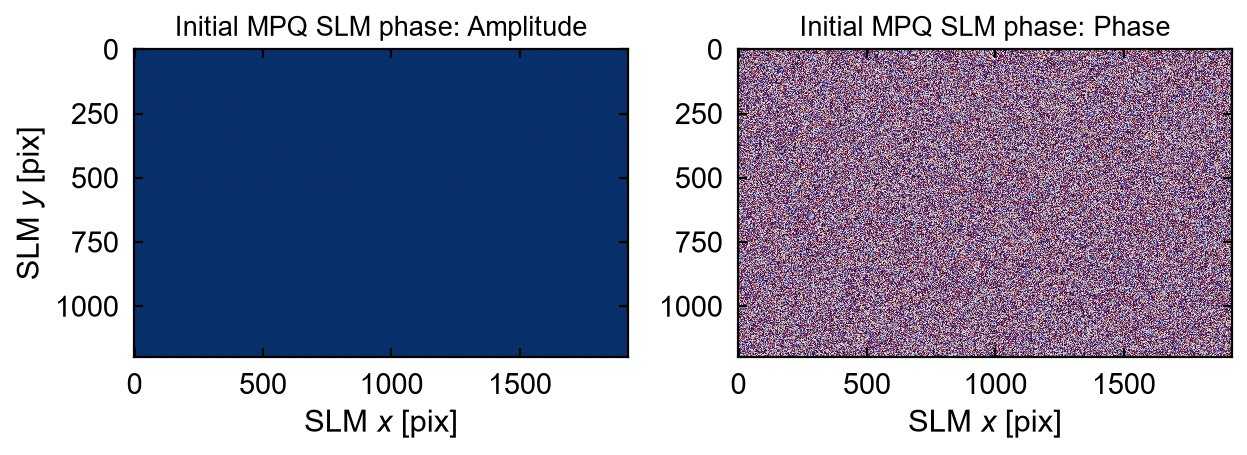

In [13]:
holo_mpq.plot_nearfield(title="Initial MPQ SLM phase")

In [14]:
holo_mpq.optimize(
    method="WGS-Leonardo",
    maxiter=50,
    feedback="computational",
    stat_groups=["computational"]
)

  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:1837: RuntimeWarning: divide by zero encountered in divide
  xp.divide(feedback_corrected, xp.array(target_amp, copy=(False if np.__version__[0] == '1' else None)), out=feedback_corrected)


In [15]:
phase_mpq = holo_mpq.get_phase()

print("All finite:", np.all(np.isfinite(phase_mpq)))
print("NaNs:", np.isnan(phase_mpq).sum())
print("Infs:", np.isinf(phase_mpq).sum())

All finite: True
NaNs: 0
Infs: 0


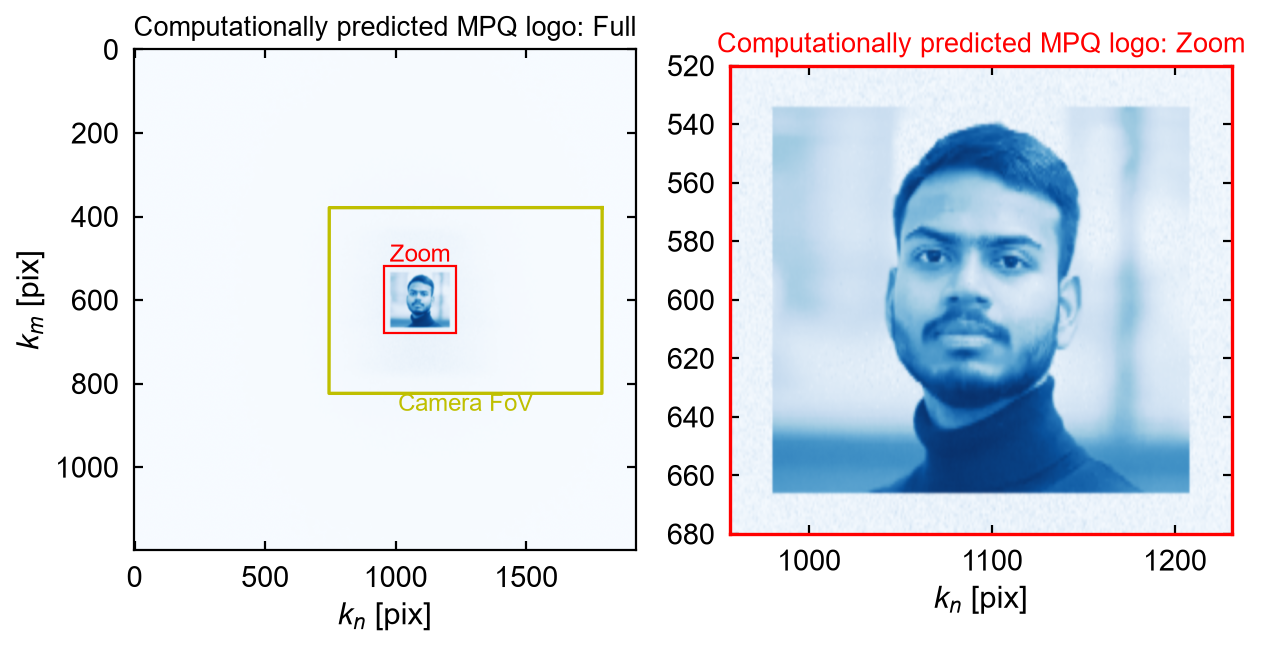

[array([ 957, 1231]), array([520, 680])]

In [16]:
holo_mpq.plot_farfield(
    title="Computationally predicted MPQ logo"
)

In [20]:
phase_mpq = holo_mpq.get_phase()

fs.slm.set_phase(
    phase_mpq,
    settle=True
)

fs.cam.flush()
img_mpq = fs.cam.get_image()

print("Image shape:", img_mpq.shape)
print("Min:", img_mpq.min())
print("Max:", img_mpq.max())

Image shape: (3672, 5496)
Min: 1
Max: 255


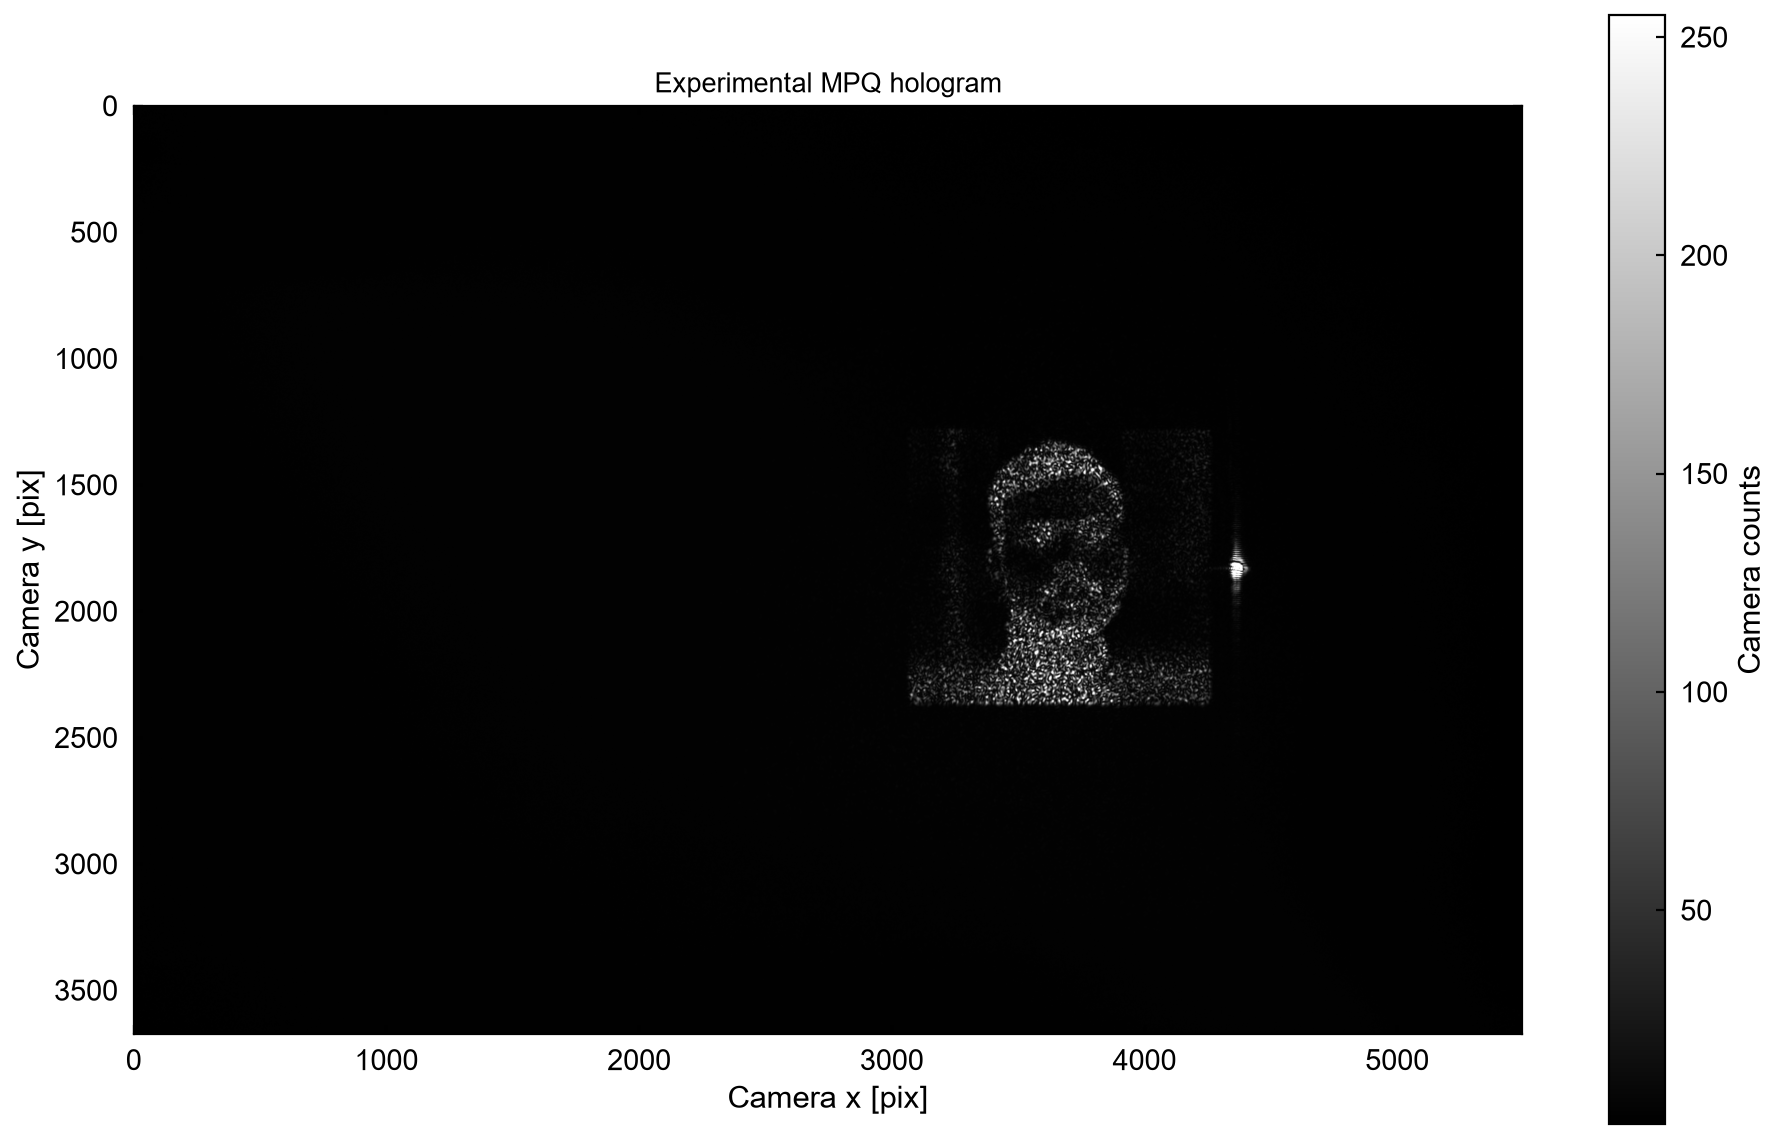

In [21]:
plt.figure(figsize=(14, 9))
plt.imshow(img_mpq, cmap="gray", origin="upper")
plt.colorbar(label="Camera counts")
plt.title("Experimental MPQ hologram")
plt.xlabel("Camera x [pix]")
plt.ylabel("Camera y [pix]")
plt.show()

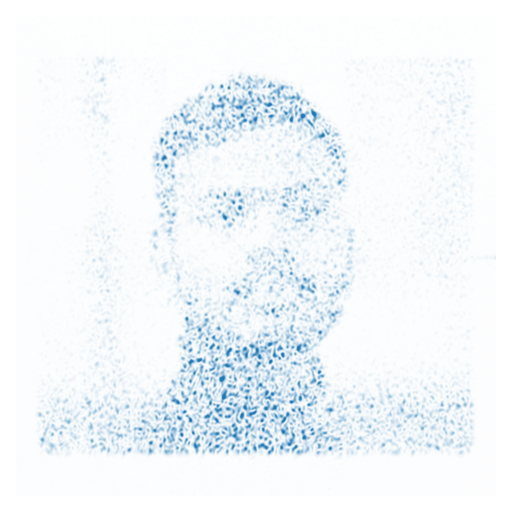

In [22]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# If your current experimental image is stored under a different name,
# replace img_mpq below with that variable name.
img_current = img_mpq

# --------------------------------
# Crop around the logo
# --------------------------------
half_size = 660   # gives a 1500 x 1500 crop

x1_crop = max(0, int(cx - half_size))
x2_crop = min(img_current.shape[1], int(cx + half_size))

y1_crop = max(0, int(cy - half_size))
y2_crop = min(img_current.shape[0], int(cy + half_size))

img_crop_mpq = img_current[y1_crop:y2_crop, x1_crop:x2_crop]

# --------------------------------
# Make a "tab:blue" colormap
# --------------------------------
tabblue_cmap = LinearSegmentedColormap.from_list(
    "white_to_tabblue",
    ["white", "tab:blue"]
)

# --------------------------------
# Plot
# --------------------------------
plt.figure(figsize=(3,3))
plt.imshow(
    img_crop_mpq,
    cmap=tabblue_cmap,
    origin="upper"
)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()